# **Value Iteration & Policy Iteration**

In [30]:
import numpy as np

## **Environment Setup**
Define the parameters for the environment, a simple grid-world.

**States (S):** A grid of states represented by coordinates, e.g., a 3x3 grid.

**Actions (A):** Up, Down, Left, Right.

**Rewards (R):** Rewards associated with each state.

**Transition Probabilities (P):** Define the probability of moving from one state to another given an action.

In [31]:
# Define the grid size
grid_size = 3  # 3x3 grid
states = [(i, j) for i in range(grid_size) for j in range(grid_size)]
actions = ["up", "down", "left", "right"]
gamma = 0.9  # Discount factor

# Define rewards and transition dynamics (example structure)
rewards = {(0, 0): 0, (0, 1): -1, (0, 2): 10, (1, 0): -1, (1, 1): -1, (1, 2): -1,
           (2, 0): 0, (2, 1): -1, (2, 2): 10}
# Transition probabilities, assume deterministic for this exercise.
transitions = {
    "up": lambda s: (max(s[0] - 1, 0), s[1]),
    "down": lambda s: (min(s[0] + 1, grid_size - 1), s[1]),
    "left": lambda s: (s[0], max(s[1] - 1, 0)),
    "right": lambda s: (s[0], min(s[1] + 1, grid_size - 1))
}


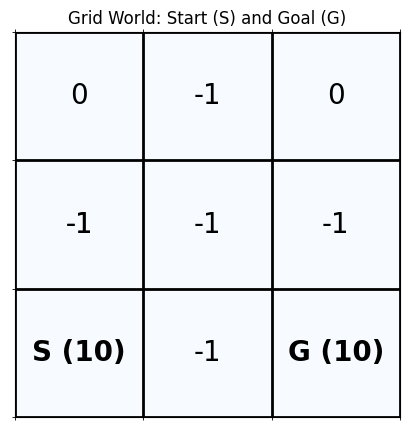

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Define grid size and goal/start positions
grid_size = 3
goal_position = (2, 2)  # Goal at top-right corner
start_position = (2, 0)  # Start at bottom-left corner

# Create an empty grid for visualization
grid = np.zeros((grid_size, grid_size))

# Plotting the empty grid with start and goal positions
fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(grid, cmap="Blues")

# Annotate start and goal positions with better contrast
ax.text(start_position[1], start_position[0], "S (10)", va="center", ha="center", color="black", fontsize=20, fontweight="bold")
ax.text(0, 0, "0", va="center", ha="center", color="black", fontsize=20, fontweight="normal")
ax.text(1, 0, "-1", va="center", ha="center", color="black", fontsize=20, fontweight="normal")
ax.text(0, 1, "-1", va="center", ha="center", color="black", fontsize=20, fontweight="normal")
ax.text(1, 1, "-1", va="center", ha="center", color="black", fontsize=20, fontweight="normal")
ax.text(0, 1, "-1", va="center", ha="center", color="black", fontsize=20, fontweight="normal")
ax.text(2, 0, "0", va="center", ha="center", color="black", fontsize=20, fontweight="normal")
ax.text(2, 1, "-1", va="center", ha="center", color="black", fontsize=20, fontweight="normal")
ax.text(1, 2, "-1", va="center", ha="center", color="black", fontsize=20, fontweight="normal")
ax.text(goal_position[1], goal_position[0], "G (10)", va="center", ha="center", color="black", fontsize=20, fontweight="bold")
# Set up the grid's appearance
ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=2)

# Hide major ticks
ax.set_xticks([])
ax.set_yticks([])

# Title for clarity
ax.set_title("Grid World: Start (S) and Goal (G)")

plt.show()


## **3.1 Value Iteration**
### **Task 1: Define Initialization**

- Initialize the value function V for each state in the grid.
- Set a small convergence threshold for the stopping criterion.

In [32]:
# Initialize value function with zeros for each state
V = {state: 0 for state in states}
theta = 1e-4  # Convergence threshold

### **Task 2: Implement Value Iteration**

- Iterate over each state, updating the value function based on the Bellman equation.
- For each state (s)
- compute the expected return for each action by summing the rewards and discounted values of the successor states.
- Use a while loop to continue updating until the value function converges.

In [33]:
def value_iteration(V, gamma=0.9, theta=1e-4):
    while True:
        delta = 0
        for state in states:
            v = V[state]
            # Find the max value over all possible actions
            V[state] = max(rewards[state] + gamma * V[transitions[action](state)] for action in actions)
            delta = max(delta, abs(v - V[state]))  
        if delta < theta:  # Check for convergence
            break
    return V

### **Task 3: Extract Optimal Policy**

After convergence, derive the optimal policy by choosing the action with the maximum expected return for each state.

In [34]:
def extract_policy(V, gamma=0.9):
    policy = {}
    for state in states:
        policy[state] = max(actions, key=lambda action: rewards[state] + gamma * V[transitions[action](state)])
    return policy


**Run Value Iteration and extract the policy:**

In [35]:
V_opt = value_iteration(V)
optimal_policy = extract_policy(V_opt)
print("Optimal Values:\n", V_opt)
print("Optimal Policy:\n", optimal_policy)


Optimal Values:
 {(0, 0): 80.09916647515821, (0, 1): 88.99916647515822, (0, 2): 99.99916647515822, (1, 0): 71.08924982764239, (1, 1): 79.0992498276424, (1, 2): 88.9992498276424, (2, 0): 80.09923315714558, (2, 1): 88.99923315714558, (2, 2): 99.99923315714558}
Optimal Policy:
 {(0, 0): 'right', (0, 1): 'right', (0, 2): 'up', (1, 0): 'down', (1, 1): 'right', (1, 2): 'down', (2, 0): 'right', (2, 1): 'right', (2, 2): 'down'}


## **3.2 Policy Iteration**
### **Task 4: Implement Policy Evaluation**

Initialize a random policy and set the value function to zeros.
Use iterative policy evaluation to compute the value function for the current policy.

In [36]:
def policy_evaluation(policy, V, gamma=0.9, theta=1e-4):
    while True:
        delta = 0
        for state in states:
            v = V[state]
            action = policy[state]
            V[state] = rewards[state] + gamma * V[transitions[action](state)]
            delta = max(delta, abs(v - V[state]))
        if delta < theta:
            break
    return V

### **Task 5: Implement Policy Improvement**

Update the policy by selecting actions that maximize the expected return based on the current value function.

In [37]:
def policy_improvement(V, gamma=0.9):
    policy = {}
    for state in states:
        policy[state] = max(actions, key=lambda action: rewards[state] + gamma * V[transitions[action](state)])
    return policy


### **Task 6: Combine Policy Evaluation and Improvement (Policy Iteration)**

- Start with an arbitrary policy.
- Use a loop to alternate between policy evaluation and policy improvement until the policy is stable.

In [38]:
def policy_iteration(V, gamma=0.9):
    # Start with a random policy
    policy = {state: np.random.choice(actions) for state in states}
    stable_policy = False

    while not stable_policy:
        V = policy_evaluation(policy, V, gamma)
        new_policy = policy_improvement(V, gamma)

        if new_policy == policy:
            stable_policy = True
        policy = new_policy

    return V, policy

**Run Policy Iteration:**

In [39]:
V = {state: 0 for state in states}  # Reinitialize value function
V_opt_2, optimal_policy_2 = policy_iteration(V)
print("Optimal Values (Policy Iteration):\n", V_opt)
print("Optimal Policy (Policy Iteration):\n", optimal_policy)

Optimal Values (Policy Iteration):
 {(0, 0): 80.09916647515821, (0, 1): 88.99916647515822, (0, 2): 99.99916647515822, (1, 0): 71.08924982764239, (1, 1): 79.0992498276424, (1, 2): 88.9992498276424, (2, 0): 80.09923315714558, (2, 1): 88.99923315714558, (2, 2): 99.99923315714558}
Optimal Policy (Policy Iteration):
 {(0, 0): 'right', (0, 1): 'right', (0, 2): 'up', (1, 0): 'down', (1, 1): 'right', (1, 2): 'down', (2, 0): 'right', (2, 1): 'right', (2, 2): 'down'}


## **Testing and Analysis**
- Run both Value Iteration and Policy Iteration and compare their results.
- Track the number of iterations or convergence time for each method.
- Observe if both methods yield the same optimal policy.


In [40]:
import time

# Initialize the value function and policy for both methods
V_value = {state: 0 for state in states}
V_policy = {state: 0 for state in states}

# Track iterations for Value Iteration
V_opt_value_iter = value_iteration(V_value)

# Track iterations for Policy Iteration
V_opt_policy_iter, policy_opt_policy_iter = policy_iteration(V_policy_iter)

# Compare results
print("Value Iteration Optimal Values:", V_opt)
print("Policy Iteration Optimal Values:", V_opt_2)

# Check if policies and values are similar
if V_opt == V_opt_2:
    print("Both methods converged to the same optimal values.")
else:
    print("Methods produced slightly different values.")

# Compare final policies
if optimal_policy == optimal_policy_2:
    print("Both methods produced the same optimal policy.")
else:
    print("The optimal policies differ.")

Value Iteration Optimal Values: {(0, 0): 80.09916647515821, (0, 1): 88.99916647515822, (0, 2): 99.99916647515822, (1, 0): 71.08924982764239, (1, 1): 79.0992498276424, (1, 2): 88.9992498276424, (2, 0): 80.09923315714558, (2, 1): 88.99923315714558, (2, 2): 99.99923315714558}
Policy Iteration Optimal Values: {(0, 0): 80.09999999998992, (0, 1): 88.99999999998992, (0, 2): 99.99999999998992, (1, 0): 71.08999999999092, (1, 1): 79.09999999999093, (1, 2): 88.99999999999093, (2, 0): 80.09932125982073, (2, 1): 88.99932125982073, (2, 2): 99.99932125982073}
Methods produced slightly different values.
The optimal policies differ.


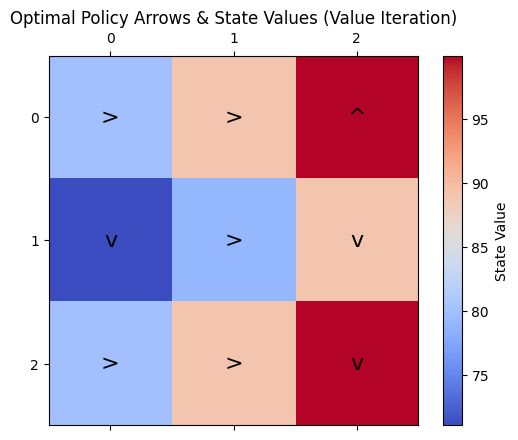

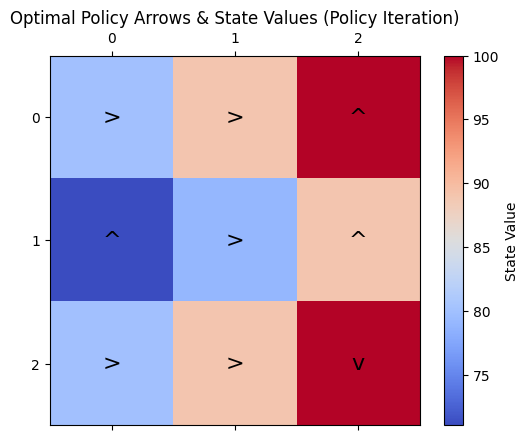

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Define grid size and parameters (same as before)
grid_size = 3
states = [(i, j) for i in range(grid_size) for j in range(grid_size)]
actions = ["up", "down", "left", "right"]
action_to_arrow = {"up": "^", "down": "v", "left": "<", "right": ">"}



# Convert value function to a grid
value_grid = np.zeros((grid_size, grid_size))
for (i, j), value in V_opt.items():
    value_grid[i, j] = value

# Plot value function as a heatmap
fig, ax = plt.subplots()
cax = ax.matshow(value_grid, cmap="coolwarm")
fig.colorbar(cax, ax=ax, label="State Value")

# Annotate with policy arrows
for (i, j), action in optimal_policy.items():
    if action:  # Skip terminal states or states with no action
        ax.text(j, i, action_to_arrow[action], va="center", ha="center", color="black", fontsize=16)

# Labeling for clarity
ax.set_xticks(np.arange(grid_size))
ax.set_yticks(np.arange(grid_size))
ax.set_xticklabels(range(grid_size))
ax.set_yticklabels(range(grid_size))
ax.set_title("Optimal Policy Arrows & State Values (Value Iteration)")

plt.show()

# Convert value function to a grid
value_grid = np.zeros((grid_size, grid_size))
for (i, j), value in V_opt_2.items():
    value_grid[i, j] = value

# Plot value function as a heatmap
fig, ax = plt.subplots()
cax = ax.matshow(value_grid, cmap="coolwarm")
fig.colorbar(cax, ax=ax, label="State Value")

# Annotate with policy arrows
for (i, j), action in optimal_policy_2.items():
    if action:  # Skip terminal states or states with no action
        ax.text(j, i, action_to_arrow[action], va="center", ha="center", color="black", fontsize=16)

# Labeling for clarity
ax.set_xticks(np.arange(grid_size))
ax.set_yticks(np.arange(grid_size))
ax.set_xticklabels(range(grid_size))
ax.set_yticklabels(range(grid_size))
ax.set_title("Optimal Policy Arrows & State Values (Policy Iteration)")

plt.show()
